# 🍌 Random walkers on the banana cube

**Experiment:** 10,000 people each pick up a banana cube that starts in the same *hardest possible* position (14 moves from solved). Each turn, every person makes **one random move**, chosen uniformly from the 13 moves (U U′ U2, E E′ E2, D D′ D2, R2 L2 F2 B2). They never think and never look.

The question is how each person's **depth in the solution tree** (the exact number of moves still needed to solve) changes over time.

Depths are exact. `banana.py` runs a breadth-first search over all 1,935,360 states, the same solver as `index.html`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import banana

B = banana.load()   # ~2 s the first time, then cached in .banana_tables.npz
print(f"{banana.N:,} states · deepest position = {B.max_depth} moves")

# chart styling
BLUE, BLUE_LIGHT, ORANGE, INK, MUTED, GRID = "#2a78d6", "#b7d3f6", "#eb6834", "#2d2614", "#8a8170", "#e9e5dc"
SEQ = LinearSegmentedColormap.from_list("seq", ["#fbfaf7", "#cde2fb", "#6da7ec", "#256abf", "#0d366b"])
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 10, "axes.edgecolor": GRID, "axes.labelcolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": MUTED, "ytick.color": MUTED,
    "lines.linewidth": 2,
})

1,935,360 states · deepest position = 14 moves


## Parameters

In [2]:
N_WALKERS = 10_000   # number of people
N_STEPS   = 400      # random moves each person makes
SEED      = 42

## The starting position

Only 576 of the 241,920 positions (0.24%) are 14 moves deep. We pick one of them, and every walker starts from that same one.

In [3]:
rng = np.random.default_rng(SEED)
deepest = np.flatnonzero(B.dist == B.max_depth)
start = int(rng.choice(deepest))
print(f"start state #{start}, depth {B.dist[start]}")
print("one shortest solution:", " ".join(B.solution(start)))

start state #184663, depth 14
one shortest solution: U R2 U F2 U2 R2 U F2 D2 R2 U' F2 D' R2


## Run the simulation

Fully vectorised: each step, all 10,000 walkers move at once through the move tables. `depth[t, i]` is walker *i*'s distance from solved after *t* random moves.

In [4]:
state = np.full(N_WALKERS, start, dtype=np.int64)
depth = np.empty((N_STEPS + 1, N_WALKERS), dtype=np.uint8)
depth[0] = B.dist[state]

for t in range(1, N_STEPS + 1):
    moves = rng.integers(0, banana.NM, size=N_WALKERS)
    state = B.step(state, moves)
    depth[t] = B.dist[state]

steps = np.arange(N_STEPS + 1)
mean = depth.mean(axis=1)
p10, p50, p90 = np.percentile(depth, [10, 50, 90], axis=1)

# a symmetric random walk on this puzzle ends up equally likely to be in any state,
# so in the long run the depths follow the share of positions at each depth
stationary_mean = (np.arange(B.max_depth + 1) * B.depth_share).sum()
print(f"mean depth after {N_STEPS} moves: {mean[-1]:.2f}   (long-run mean = {stationary_mean:.2f})")

mean depth after 400 moves: 9.72   (long-run mean = 9.72)


## 1 · Every walker's depth over time

Thin lines are 150 individual walkers, with a small vertical jitter so the lines don't stack on the integer depths. The blue line is the mean of all 10,000 walkers, and the band covers the 10th to 90th percentile.

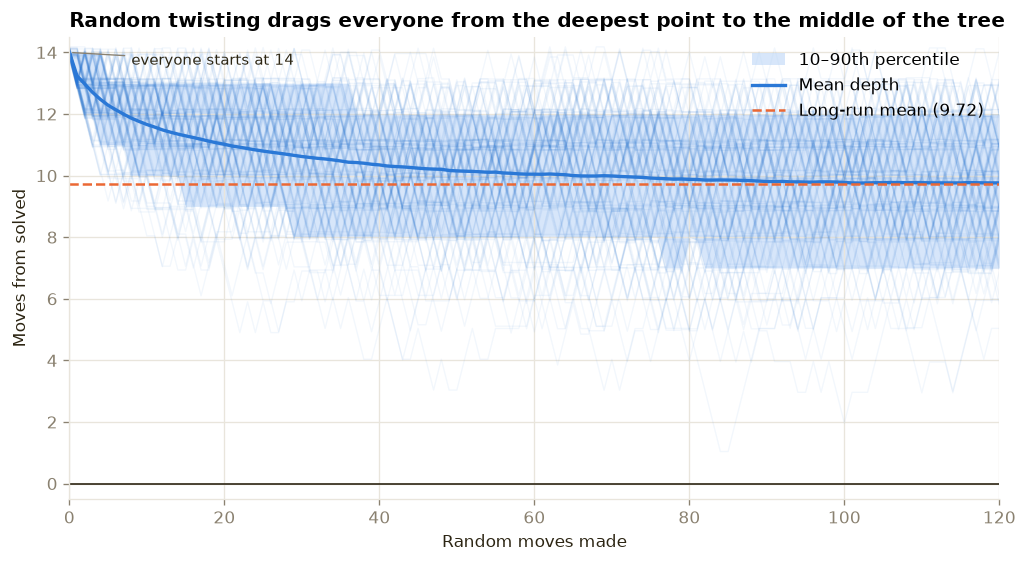

In [5]:
SHOW_STEPS = 120   # the interesting part happens early
fig, ax = plt.subplots(figsize=(10, 5))
sample = rng.choice(N_WALKERS, 150, replace=False)
jitter = rng.uniform(-0.18, 0.18, size=150)
s = steps[:SHOW_STEPS + 1]
ax.plot(s, depth[:SHOW_STEPS + 1, sample] + jitter, color=BLUE, alpha=0.06, linewidth=0.8)
ax.fill_between(s, p10[:SHOW_STEPS + 1], p90[:SHOW_STEPS + 1], color=BLUE_LIGHT, alpha=0.55, linewidth=0, label="10–90th percentile")
ax.plot(s, mean[:SHOW_STEPS + 1], color=BLUE, label="Mean depth")
ax.axhline(stationary_mean, color=ORANGE, linestyle="--", linewidth=1.5, label=f"Long-run mean ({stationary_mean:.2f})")
ax.axhline(0, color=INK, linewidth=1)
ax.annotate("everyone starts at 14", (0, 14), xytext=(8, 13.6), color=INK, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set(xlim=(0, SHOW_STEPS), ylim=(-0.5, B.max_depth + 0.5), yticks=range(0, B.max_depth + 1, 2),
       xlabel="Random moves made", ylabel="Moves from solved")
ax.set_title("Random twisting drags everyone from the deepest point to the middle of the tree")
ax.legend(loc="upper right", frameon=False)
plt.show()

## 2 · Where the crowd is in the tree

Each column is a moment in time. The colour shows what share of the 10,000 walkers sit at each depth. The right panel compares where they end up with the share of all positions at each depth.

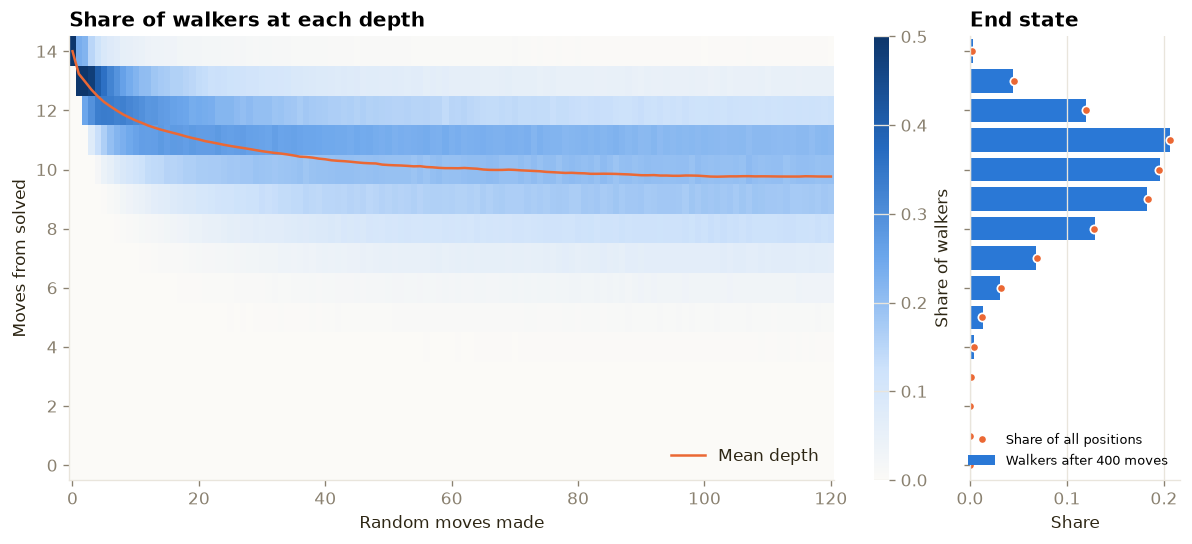

In [6]:
occupancy = np.stack([np.bincount(row, minlength=B.max_depth + 1) for row in depth], axis=1) / N_WALKERS

fig, (ax, cax, ax2) = plt.subplots(1, 3, figsize=(11.5, 4.8), gridspec_kw={"width_ratios": [4, 0.08, 1.1], "wspace": 0.12})
ax2.sharey(ax)
im = ax.imshow(occupancy[:, :SHOW_STEPS + 1], origin="lower", aspect="auto", cmap=SEQ,
               extent=(-0.5, SHOW_STEPS + 0.5, -0.5, B.max_depth + 0.5), vmin=0, vmax=0.5)
ax.plot(steps[:SHOW_STEPS + 1], mean[:SHOW_STEPS + 1], color=ORANGE, linewidth=1.5, label="Mean depth")
ax.grid(False)
ax.set(xlabel="Random moves made", ylabel="Moves from solved", yticks=range(0, B.max_depth + 1, 2))
ax.set_title("Share of walkers at each depth")
ax.legend(loc="lower right", frameon=False, labelcolor=INK)
cb = fig.colorbar(im, cax=cax)
cb.set_label("Share of walkers"); cb.outline.set_visible(False)

d = np.arange(B.max_depth + 1)
final = np.bincount(depth[-1], minlength=B.max_depth + 1) / N_WALKERS
ax2.barh(d, final, height=0.8, color=BLUE, label=f"Walkers after {N_STEPS} moves")
ax2.plot(B.depth_share, d, "o", color=ORANGE, markersize=5, markeredgecolor="white", label="Share of all positions")
ax2.set(xlabel="Share")
ax2.tick_params(labelleft=False)
ax2.set_position(ax2.get_position().translated(0.03, 0))
ax2.set_title("End state")
ax2.legend(loc="lower right", frameon=False, fontsize=8)
ax2.grid(axis="y", visible=False)
plt.show()

## 3 · Does anyone ever solve it by luck?

The left chart shows the share of walkers that have touched depth 0 (solved) at least once. The right chart shows the best (lowest) depth each walker has reached so far, averaged over all walkers.

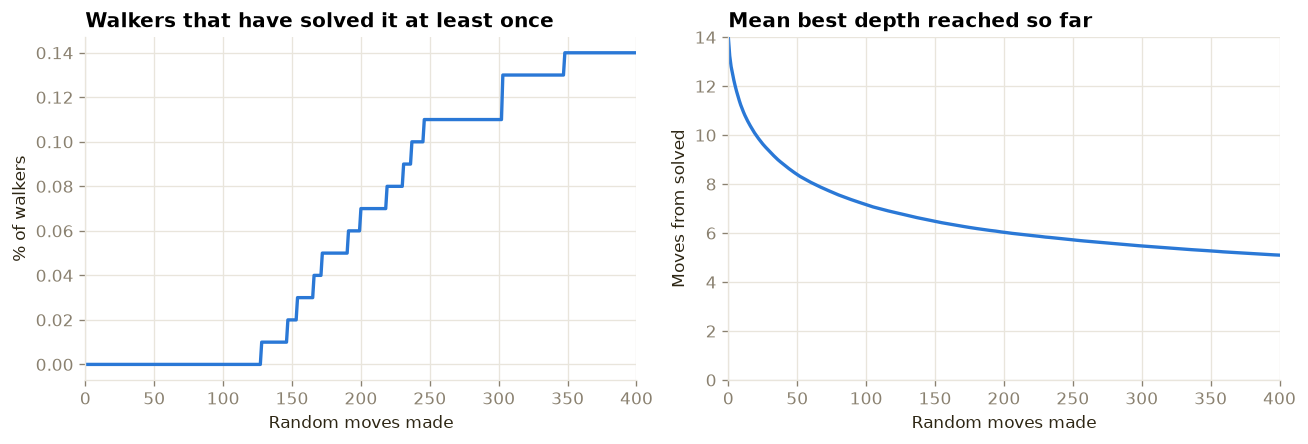

0.14% of walkers (14 people) hit solved within 400 moves


In [7]:
ever_solved = (np.minimum.accumulate(depth, axis=0) == 0).mean(axis=1)
best_so_far = np.minimum.accumulate(depth, axis=0).mean(axis=1)

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.8))
a.plot(steps, ever_solved * 100, color=BLUE)
a.set(xlabel="Random moves made", ylabel="% of walkers", xlim=(0, N_STEPS))
a.set_title("Walkers that have solved it at least once")
b.plot(steps, best_so_far, color=BLUE)
b.set(xlabel="Random moves made", ylabel="Moves from solved", xlim=(0, N_STEPS), ylim=(0, B.max_depth))
b.set_title("Mean best depth reached so far")
plt.tight_layout(); plt.show()

print(f"{ever_solved[-1]*100:.2f}% of walkers ({int(round(ever_solved[-1]*N_WALKERS))} people) hit solved within {N_STEPS} moves")

## Summary

In [8]:
settle = int(np.argmax(np.abs(mean - stationary_mean) < 0.1))
closest_to_solved = int(depth.min())
print(f"Start depth:                       {B.max_depth}")
print(f"Mean depth reaches long-run value: after ~{settle} moves")
print(f"Long-run mean depth:               {stationary_mean:.2f}  (median {int(np.searchsorted(np.cumsum(B.depth_share), 0.5))})")
print(f"Closest any walker got:            {closest_to_solved}")
print(f"Expected wait for a lucky solve:   ~{banana.N // 8:,} random moves  (1 in {banana.N // 8:,} positions is solved)")

Start depth:                       14
Mean depth reaches long-run value: after ~90 moves
Long-run mean depth:               9.72  (median 10)
Closest any walker got:            0
Expected wait for a lucky solve:   ~241,920 random moves  (1 in 241,920 positions is solved)


## What's going on

* **The pull to the middle is a counting effect.** A random move has no idea where "solved" is. Most positions are 9 to 11 moves deep, so most moves go towards that depth: at depth 14, almost every move leads shallower because there is hardly anything deeper. Near solved, almost every move leads deeper.
* **The crowd falls fast, then settles slowly.** Most of the drop happens in the first 20 or so moves, but the mean only gets within 0.1 of its long-run value after about 90. After that, the depth spread matches the share of all 241,920 positions at each depth. Every move has its inverse in the move set, so a random walk on the puzzle visits every state equally often in the long run.
* **Luck essentially never solves it.** Solved positions are 8 of 1,935,360 states (8 because there are 8 ways to hold it). A random walker needs roughly 240,000 moves on average to stumble onto one. With the default settings, only about 14 of the 10,000 people (0.14%) hit solved within 400 moves, roughly what that 1-in-240,000 chance per move predicts.

### Ideas to try next
* Change `N_STEPS` to 5,000 and see how many people get lucky.
* Ban undoing the previous move (no `U` right after `U′`). Does the crowd settle faster?
* Start from depth 1 instead of depth 14. The walkers drift *away* from solved just as reliably.
* Make each walker *greedy* with probability *p*: they pick a closer move whenever one exists. How much skill does it take to beat the random pull?